# ANOVA and Mixed model

In [1]:
from pathlib import Path
import sys # for setting the importing env  

project_dir = Path.cwd().parent.parent # Adjust here to get the project_dir

# Add project_dir to sys.path at the first position
if project_dir not in sys.path:
    sys.path.insert(0, str(project_dir))

## Imports

In [ ]:
import pandas as pd

from statsmodels.formula.api import logit, ols, gls, glm, mixedlm
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm

from matplotlib import pyplot as plt
import seaborn as sns

## Data

In [3]:
# Load data
data = pd.read_csv(project_dir / 'data/mixed-model-gpt_20260529/demo_longitudinal_biomarker.csv')

print(f"Data shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")

Data shape: (321, 8)
Columns: ['id', 'time', 'diagnosis', 'age', 'sex', 'medication', 'site', 'biomarker']


## Explore data in plots

Overall mean biomarker: 62.89
Group means by time:
time
0    61.486432
1    63.201748
2    64.258475
Name: biomarker, dtype: float64


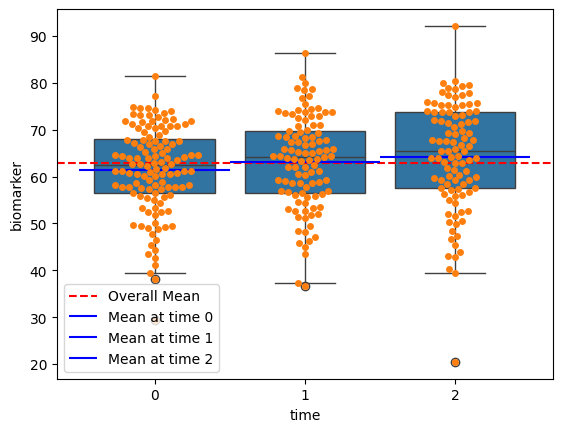

In [4]:
overall_mean = data['biomarker'].mean()
print(f"Overall mean biomarker: {overall_mean:.2f}")
group_means = data.groupby('time')['biomarker'].mean()
print("Group means by time:")
print(group_means)


sns.boxplot(x='time', y='biomarker', data=data)
sns.swarmplot(x='time', y='biomarker', data=data)

# Add horizontal line for overall mean
plt.axhline(overall_mean, color='red', linestyle='--', label='Overall Mean')

# Add group means
for time_point, mean_value in group_means.items():
    plt.hlines(mean_value, xmin=time_point-0.5, xmax=time_point+0.5, color='blue', linestyle='-', label=f'Mean at time {time_point}')


plt.legend()




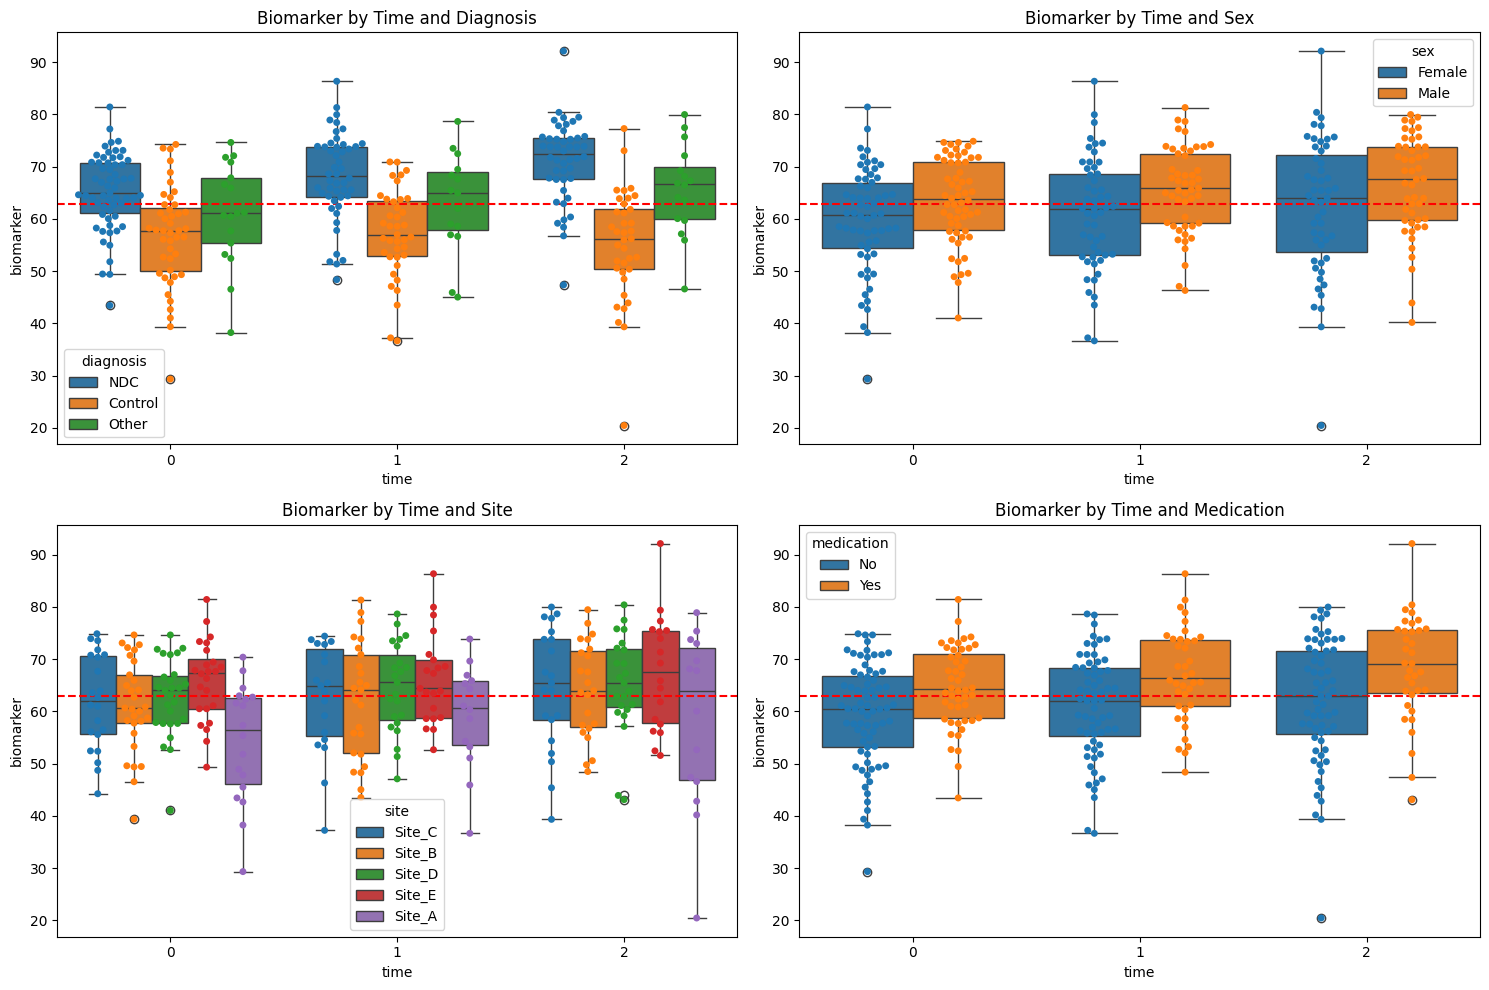

In [5]:

hues = ['diagnosis', 'sex', 'site', 'medication']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for hue, ax in zip(hues, axes.flatten()):
    sns.boxplot(x='time', y='biomarker', hue=hue, data=data, ax=ax)
    sns.swarmplot(x='time', y='biomarker', hue=hue, data=data, ax=ax, dodge=True, legend=False)
    ax.set_title(f'Biomarker by Time and {hue.capitalize()}')
    ax.legend(title=hue)

    ax.axhline(overall_mean, color='red', linestyle='--', label='Overall Mean')

plt.tight_layout()
plt.show()

<Axes: xlabel='time', ylabel='biomarker'>

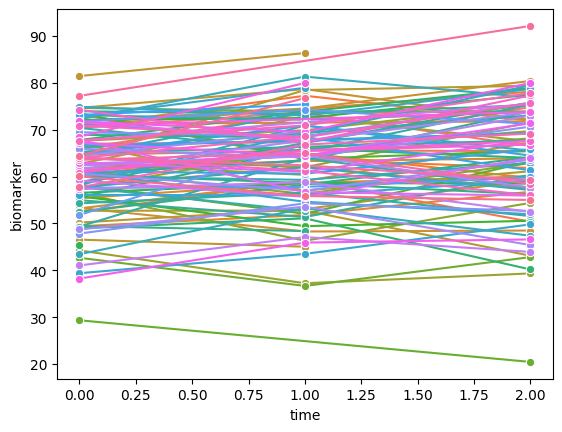

In [6]:
# spaghetti plot
sns.lineplot(x='time', y='biomarker', data=data, hue='id', legend=False, marker='o')

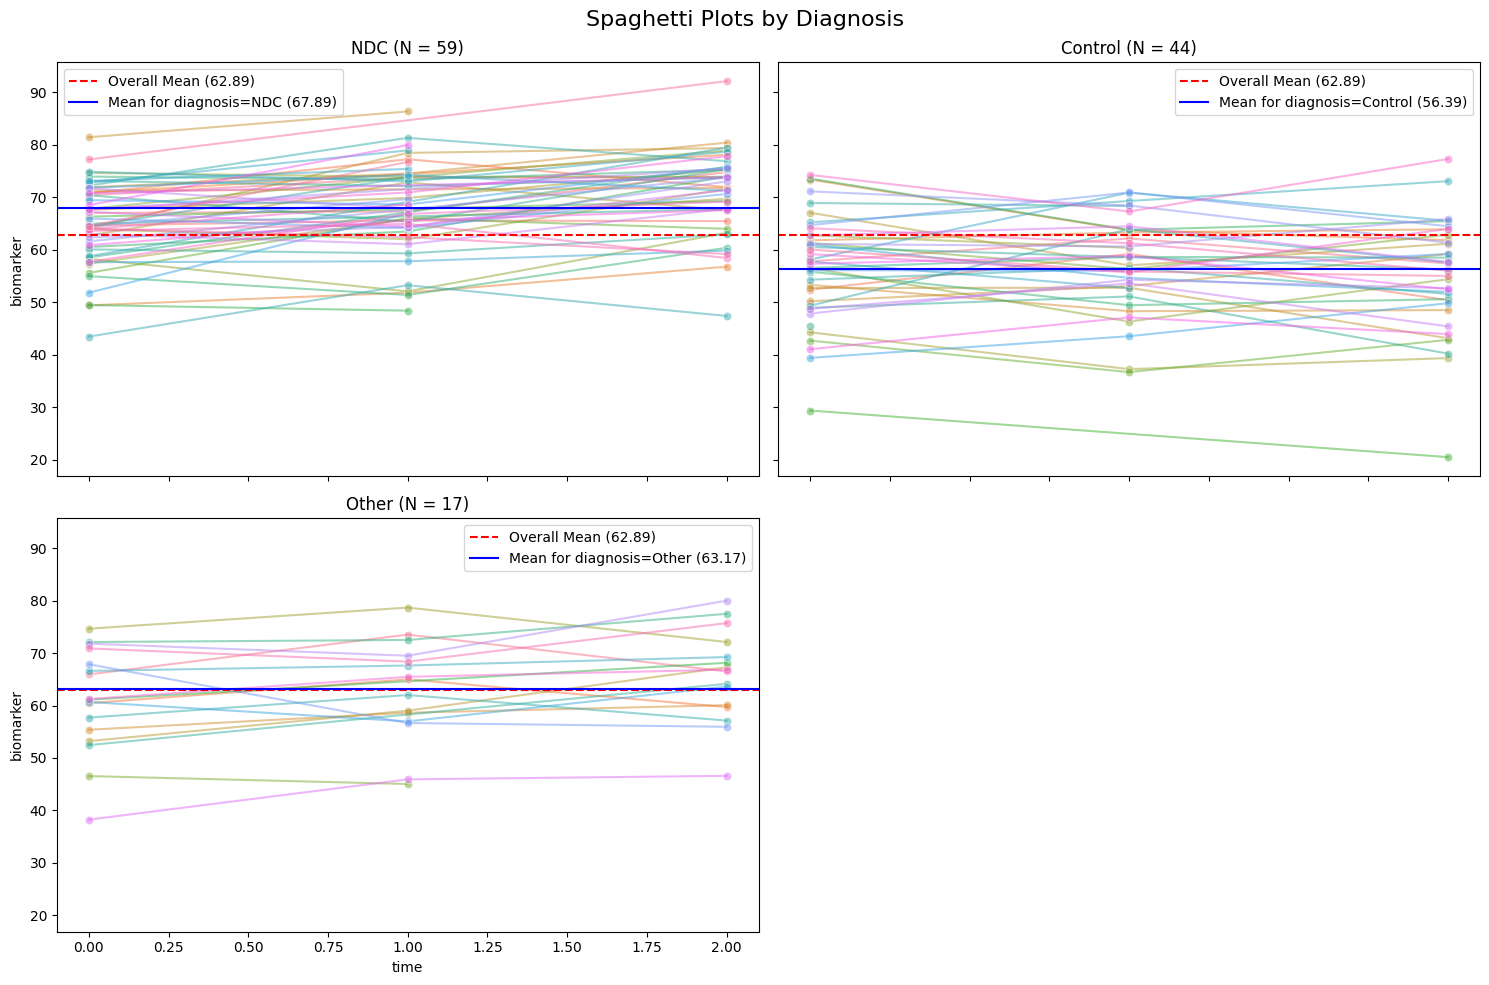

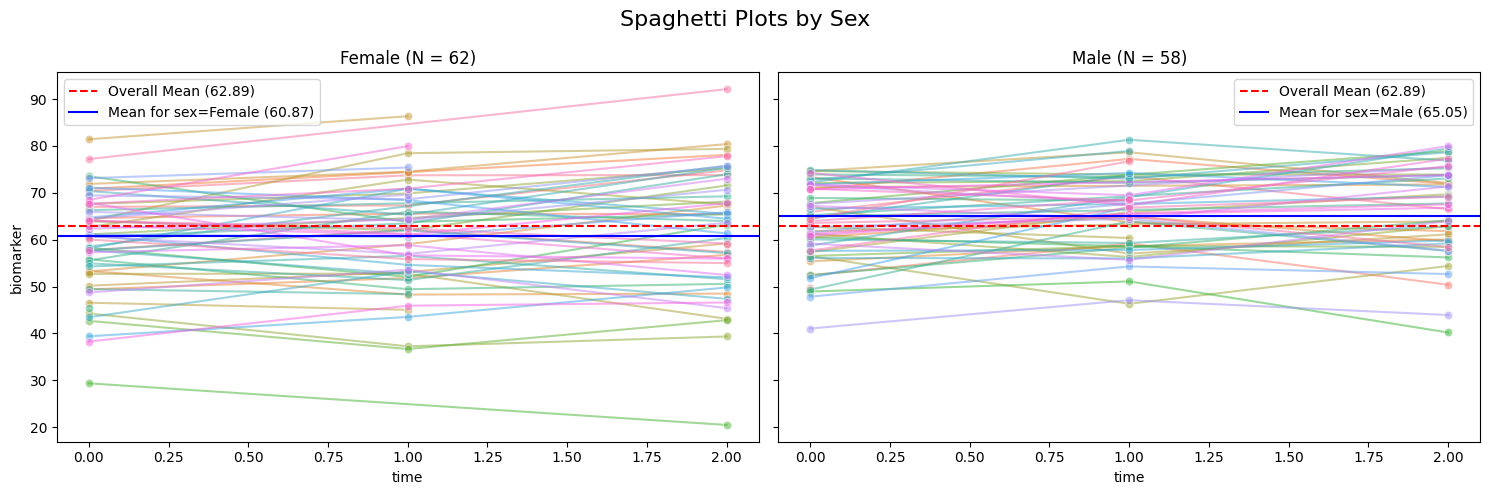

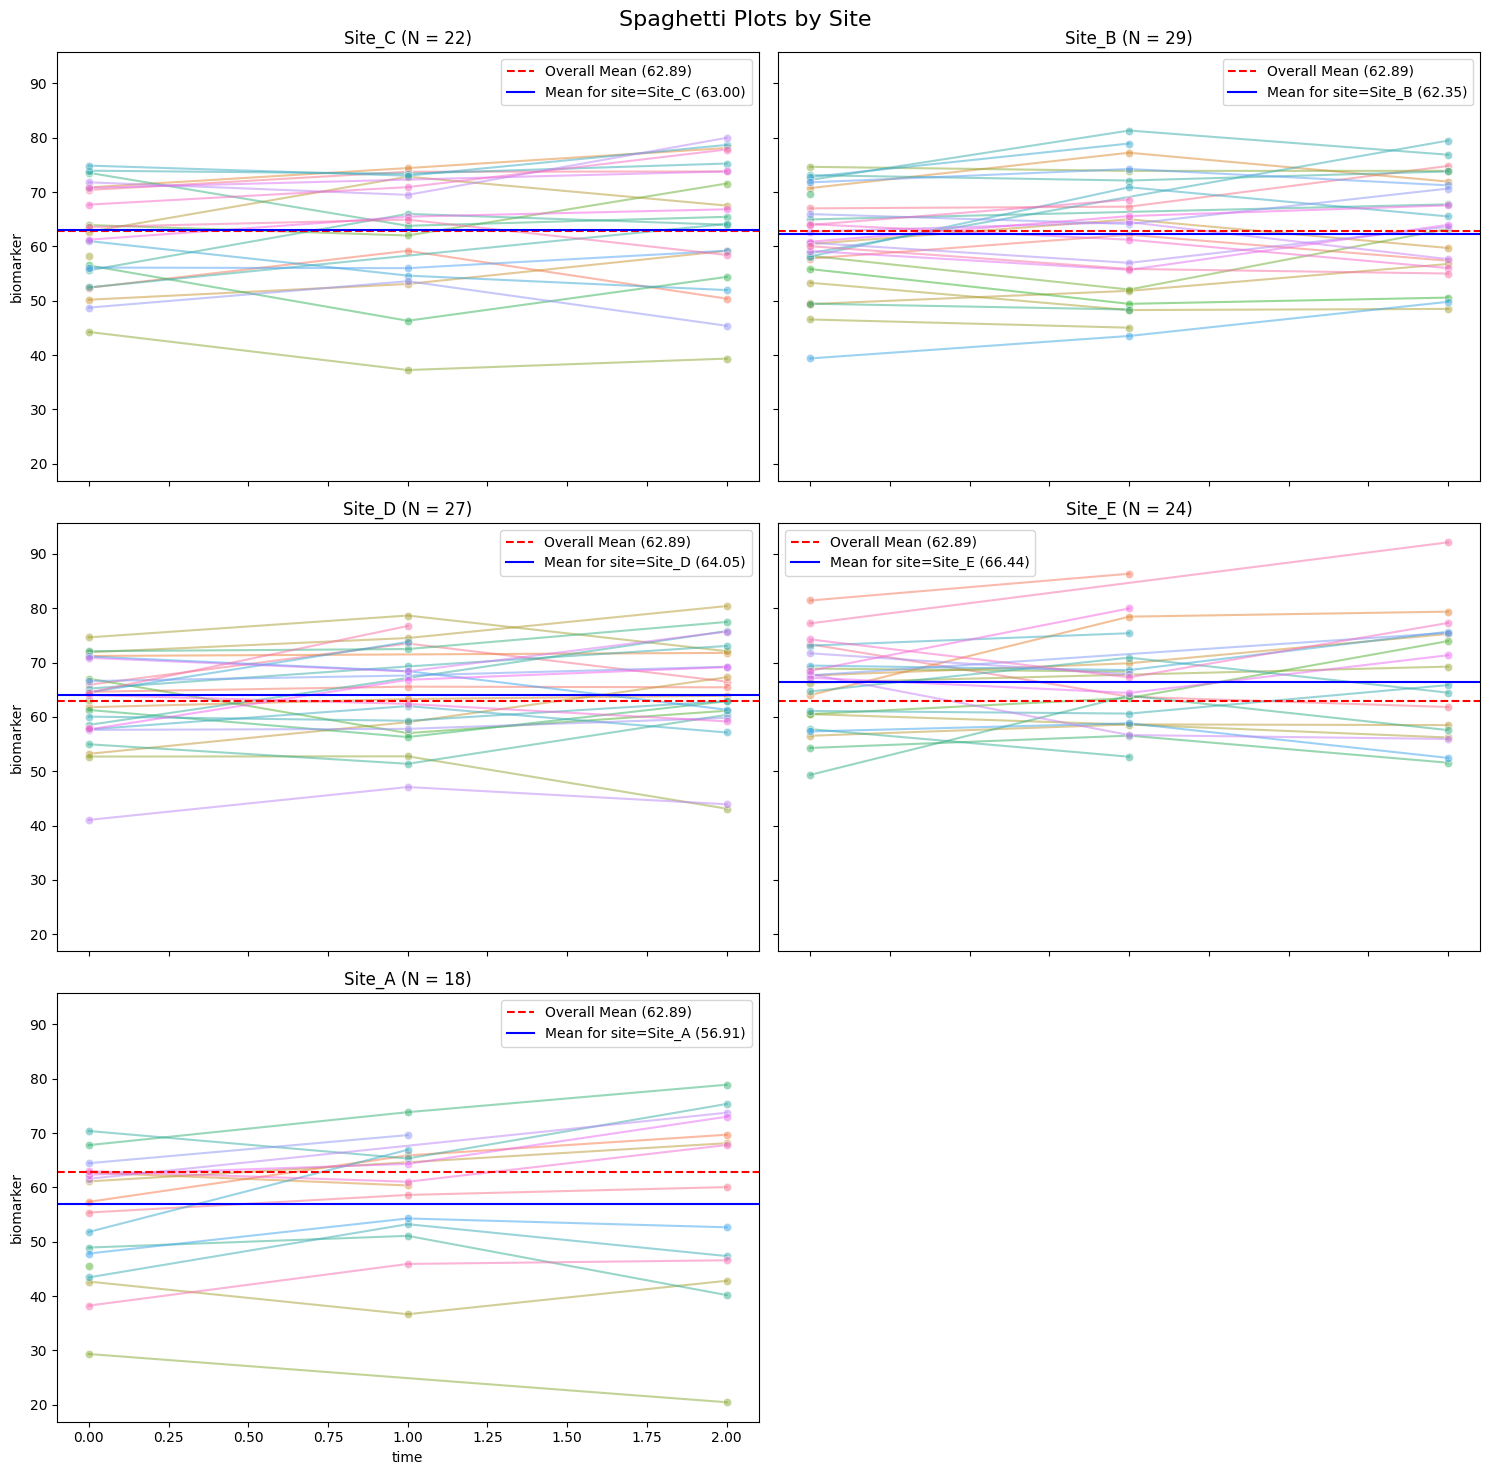

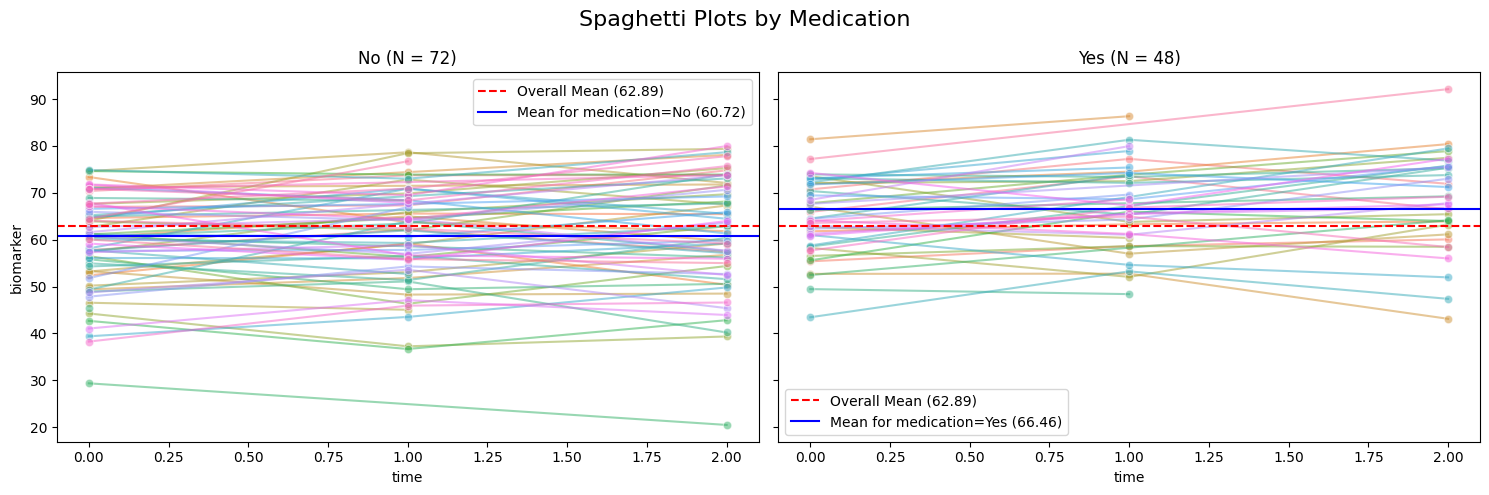

In [7]:

def fig_spaghetti_by_group(data: pd.DataFrame, x_col:str, y_col:str, id_col:str, group_col: str):
    subgroups = data[group_col].unique()

    overall_mean = data[y_col].mean()
    subgroup_means = data.groupby(group_col)[y_col].mean()
    
    fig_cols = 2
    fig_rows = (len(subgroups) + 1) // fig_cols

    fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(15, 5 * fig_rows), sharex=True, sharey=True)

    for subgroup, ax in zip(subgroups, axes.flatten()):
        subgroup_idx = data[group_col] == subgroup
        sns.lineplot(x=x_col, y=y_col, data=data[subgroup_idx], hue=id_col, legend=False, marker='o', ax=ax, alpha=0.5)
        ax.set_title(f'{subgroup} (N = {len(data[subgroup_idx][id_col].unique())})')
        ax.axhline(overall_mean, color='red', linestyle='--', label=f'Overall Mean ({overall_mean:.2f})')
        s_mean = subgroup_means.loc[subgroup]
        ax.axhline(s_mean, color='blue', linestyle='-', label=f'Mean for {group_col}={subgroup} ({s_mean:.2f})')
        ax.legend()

    # remove blank subplots
    for i in range(len(subgroups), len(axes.flatten())):
        fig.delaxes(axes.flatten()[i])

    fig.suptitle(f'Spaghetti Plots by {group_col.capitalize()}', fontsize=16)
    fig.tight_layout()

 
for group_col in hues:
    fig_spaghetti_by_group(data, x_col='time', y_col='biomarker', id_col='id', group_col=group_col)

## Linear fitting and mixed model

The goal is to see why mixed model is better than linear regression in this case. 

Mixed model is an advanced statistical technique that beginners may not be familiar with.

Mixed model is a generalization of linear regression that allows for both fixed and random effects. 

In this case, we have repeated measurements of the same subjects over time, which violates the independence assumption of linear regression.

Fitting: $biomarker \sim time$

## 

In [17]:
# ols: assumes a normal linear model
model = ols('biomarker ~ time', data=data).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              biomarker   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     4.089
Date:                Sat, 06 Jun 2026   Prob (F-statistic):             0.0440
Time:                        18:59:31   Log-Likelihood:                -1199.5
No. Observations:                 321   AIC:                             2403.
Df Residuals:                     319   BIC:                             2411.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     61.5816      0.860     71.612      0.0

In [ ]:

model = gls('biomarker ~ time', data=data).fit()
print(model.summary())

                            GLS Regression Results                            
Dep. Variable:              biomarker   R-squared:                       0.013
Model:                            GLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     4.089
Date:                Sat, 06 Jun 2026   Prob (F-statistic):             0.0440
Time:                        17:54:24   Log-Likelihood:                -1199.5
No. Observations:                 321   AIC:                             2403.
Df Residuals:                     319   BIC:                             2411.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     61.5816      0.860     71.612      0.0

In [9]:
model = glm('biomarker ~ time', data=data).fit()
print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              biomarker   No. Observations:                  321
Model:                            GLM   Df Residuals:                      319
Model Family:                Gaussian   Df Model:                            1
Link Function:               Identity   Scale:                          103.73
Method:                          IRLS   Log-Likelihood:                -1199.5
Date:                Sat, 06 Jun 2026   Deviance:                       33091.
Time:                        16:48:38   Pearson chi2:                 3.31e+04
No. Iterations:                     3   Pseudo R-squ. (CS):            0.01268
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     61.5816      0.860     71.612      0.0

In [10]:
model = mixedlm('biomarker ~ time', data=data, groups=data['id']).fit(reml=False)
print(model.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: biomarker 
No. Observations: 321     Method:             ML        
No. Groups:       120     Scale:              18.7337   
Min. group size:  1       Log-Likelihood:     -1080.2167
Max. group size:  3       Converged:          Yes       
Mean group size:  2.7                                   
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     61.553    0.928 66.304 0.000 59.734 63.373
time           1.542    0.301  5.125 0.000  0.952  2.131
Group Var     87.248    3.584                           



In [11]:
model = mixedlm('biomarker ~ time', data=data, groups=data['id']).fit(reml=True)
print(model.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: biomarker 
No. Observations: 321     Method:             REML      
No. Groups:       120     Scale:              18.8265   
Min. group size:  1       Log-Likelihood:     -1079.6949
Max. group size:  3       Converged:          Yes       
Mean group size:  2.7                                   
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     61.553    0.932 66.034 0.000 59.726 63.380
time           1.542    0.302  5.112 0.000  0.951  2.133
Group Var     88.014    3.618                           



In [14]:
# Add time as a random slope
model = mixedlm(
    "biomarker ~ time",
    data,
    groups="id",
    re_formula="~time"
).fit(reml=True)
print(model.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: biomarker 
No. Observations: 321     Method:             REML      
No. Groups:       120     Scale:              14.7726   
Min. group size:  1       Log-Likelihood:     -1069.9858
Max. group size:  3       Converged:          Yes       
Mean group size:  2.7                                   
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     61.539    0.837 73.519 0.000 59.898 63.180
time           1.589    0.331  4.799 0.000  0.940  2.237
id Var        71.290    4.294                           
id x time Cov  8.725    0.799                           
time Var       4.013    0.627                           



In [15]:
# Add time as a random slope
model = mixedlm(
    "biomarker ~ time",
    data,
    groups="id",
    re_formula="~time"
).fit(reml=False)
print(model.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: biomarker 
No. Observations: 321     Method:             ML        
No. Groups:       120     Scale:              14.7752   
Min. group size:  1       Log-Likelihood:     -1070.5342
Max. group size:  3       Converged:          Yes       
Mean group size:  2.7                                   
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     61.539    0.834 73.827 0.000 59.906 63.173
time           1.588    0.329  4.820 0.000  0.942  2.234
id Var        70.589    4.250                           
id x time Cov  8.712    0.789                           
time Var       3.900    0.619                           

